<a href="https://colab.research.google.com/github/Dia-git/energy-market-intelligence-ml/blob/main/notebooks/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BCI Common Recruitment Exercise: Energy Market Data Analysis**

Candidate Name: Diana Cristina Nicutari

Date: 27/02/2026


# 📚 The Guide to This Analysis

This section explains the "why" and "how" behind the code below.

### 🛠️ 1. The Python Tools Used
* **`pandas`:** It allows loading large CSV files, merging them together, and manipulating millions of rows of data instantly.
* **`matplotlib` & `seaborn`:** These libraries take the raw numbers and turn them into the charts, graphs, and scatter plots you see above.
* **`scikit-learn`:** The industry standard for Machine Learning. I used this for the clustering algorithm.
* **`statsmodels`:** A statistical toolkit that was used to look at past time and predict future trends (forecasting).

### 🗂️ 2. Datasets Used
The data comes from the **UN Energy Statistics Database (UNdata)**. However, the UN portal has a hard limit: you can only download 100,000 rows at a time.
* **The Fix:** Instead of downloading everything, I specifically searched for and downloaded four targeted "slices" of data: Total Wind, Total Solar, Gross Production, and Final Consumption. This bypassed the limit and was the best option to download exactly the raw materials needed.

### 🏃 3. Finding the "Sprinters" (Growth Velocity)
When looking for countries adopting renewable energy, it’s easy to just look at who has the most solar panels (like China or the USA). But the task was to find who was *accelerating* the fastest.

* **The 100m kWh Rule:** If a tiny island builds its first solar panel, its growth rate would look like 5,000%. To prevent this "math trick" from ruining the results, the code enforces a rule: a country must already produce at least 100 million kWh of energy to be included in the ranking.

### 🤖 4. Grouping the World (Machine Learning)
A Machine Learning algorithm called **K-Means Clustering** was used to group countries.
*  The algorithm was provided two features to look at: **Grid Size** and **Renewable Percentage**. It then "naturally" found 4 distinct "tribes" or clusters of countries.
* **The Log Scale:** China produces millions of times more energy than Malta. If we put them on a normal chart, China would be off the screen, and everyone else would be squished at the bottom. We applied a "Logarithmic Scale" (Log1p), which mathematically shrinks the gaps so we can compare the "elephants" and the "mice" on the exact same chart.

### 🔮 5. Predicting the Future (Forecasting)
To predict the UK's wind energy in 2030, a statistical method called **Holt-Winters Exponential Smoothing** was applied.
* Why this model? Some trends are straight lines. But wind energy in the UK is **compounding** (it is growing faster and faster every year). The Holt-Winters method is smart enough to look at the "shape" of the past data, recognize that it is curving upwards (an "additive trend"), and accurately carry that curve forward into 2030.

### 🕵️ 6. The Sanity Check (Data Quality)
In the UN database, some countries (like China) had submitted their paperwork for 2024, but others (like the USA and India) hadn't submitted past 2023 yet.
* To make sure we were comparing "apples to apples," our final test locked the analysis window strictly to **2019 -  2023**. By ignoring the incomplete 2024 data, we proved that the massive growth in emerging markets wasn't just a glitch in the paperwork, it is a real, sustained global trend.

# 1. Data Initialization

This section loads the four primary datasets extracted from the UNdata portal. To optimize performance and ensure data integrity, we merge the individual CSV files into a single master dataframe, allowing for cross-commodity comparisons.

In [ ]:
import pandas as pd

# 1. LOAD THE FOUR DATASETS
print("Loading data...")
wind_df = pd.read_csv('wind.csv')
solar_df = pd.read_csv('solar.csv')
prod_df = pd.read_csv('production.csv')
cons_df = pd.read_csv('consumption.csv')

# 2. STANDARDIZE AND MERGE
# We combine them into a single working dataframe
df = pd.concat([wind_df, solar_df, prod_df, cons_df], ignore_index=True)

# 3. INSPECT THE DATA
# This prints the column names and the first 5 rows so we know exactly what we are working with
print("\n--- Column Names ---")
print(df.columns.tolist())
print("\n--- First 5 Rows ---")
display(df.head())

Loading data...

--- Column Names ---
['Country or Area', 'Commodity - Transaction', 'Year', 'Unit', 'Quantity', 'Quantity Footnotes']

--- First 5 Rows ---


,Country or Area,Commodity - Transaction,Year,Unit,Quantity,Quantity Footnotes
0,Algeria,Electricity - total wind production,2023.0,"Kilowatt-hours, million",13.57,NaN
1,Algeria,Electricity - total wind production,2022.0,"Kilowatt-hours, million",15.78,NaN
2,Algeria,Electricity - total wind production,2021.0,"Kilowatt-hours, million",11.00,NaN
3,Algeria,Electricity - total wind production,2020.0,"Kilowatt-hours, million",8.00,NaN
4,Algeria,Electricity - total wind production,2019.0,"Kilowatt-hours, million",10.00,NaN


# 2. Global Growth Analysis (Aggressive Adopters)

To identify the world's most "aggressive" adopters, we filter the dataset for wind and solar production. This script calculates the Year-over-Year (YoY) growth rate over the last five years. We apply a baseline threshold of 100 million kWh to eliminate statistical "noise" from tiny energy grids and ensure we are focusing on meaningful infrastructure expansion.

In [ ]:
# STEP 4: FIND THE AGGRESSIVE ADOPTERS (GLOBAL TRENDS)

# 1. Filter for Wind and Solar
# We use regex to find any row where the transaction contains 'wind' or 'solar'
renewables_df = df[df['Commodity - Transaction'].str.contains('wind|solar', case=False, na=False)].copy()

# 2. Pivot the data: Countries as rows, Years as columns
growth_table = renewables_df.pivot_table(index='Country or Area', columns='Year', values='Quantity', aggfunc='sum')

# 3. Apply the Baseline Threshold (Data Quality Check)
# We only want to analyze countries that produced at least 100 million kWh in the most recent year available
# This strips out the statistical "noise" of tiny grids
recent_year = growth_table.columns[-1]
valid_countries = growth_table[growth_table[recent_year] > 100].index
filtered_growth_table = growth_table.loc[valid_countries]

# 4. Calculate Year-over-Year (YoY) Growth for the last 5 years
# .pct_change() calculates the percentage jump from the previous year
# We take the mean (average) of the last 5 columns to get the recent 5-year trajectory
recent_growth_rates = filtered_growth_table.pct_change(axis=1, fill_method=None).iloc[:, -5:].mean(axis=1) * 100

# 5. Sort and Display the Top 10
top_adopters = recent_growth_rates.sort_values(ascending=False).head(10)

print("--- TOP 10 AGGRESSIVE ADOPTERS (Avg Annual % Growth over last 5 years) ---")
print(top_adopters.round(2).astype(str) + ' %')

--- TOP 10 AGGRESSIVE ADOPTERS (Avg Annual % Growth over last 5 years) ---
Country or Area
Malawi        4441.06 %
Djibouti      2347.23 %
Oman           363.65 %
Uzbekistan     337.39 %
Indonesia      130.73 %
Albania        118.63 %
Bahrain         55.44 %
Myanmar         47.12 %
Mali            43.65 %
Kazakhstan      33.81 %
dtype: object


# 3. Machine Learning: Global Energy Mix Clustering

Using the K-Means algorithm, we segment countries into four distinct clusters based on their energy mix (Renewable % vs. Total Grid Size). Because global energy output varies by several orders of magnitude, we apply a logarithmic scale to the total grid size to ensure the clustering remains mathematically balanced across all nation types.

Preparing data for K-Means Clustering...


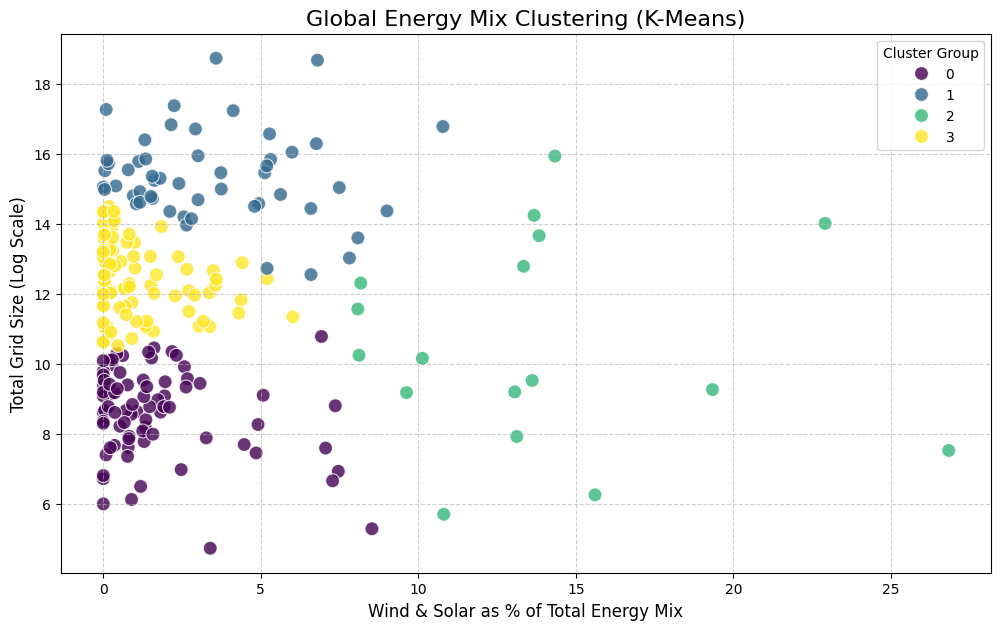


--- Cluster Summary Profiles ---
         Renewable_Pct  Total_Energy
Cluster                             
0                 1.68       9908.48
1                 3.39   11919112.30
2                13.80     756431.54
3                 1.01     433957.91


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Preparing data for K-Means Clustering...")

# 1. Isolate Total Production vs Wind/Solar Production
# We use regex to grab the high-level production totals
total_df = df[df['Commodity - Transaction'].str.contains('Gross production|net production', case=False, na=False)]

# Group by country to get total all-time energy sum for this dataset
total_by_country = total_df.groupby('Country or Area')['Quantity'].sum()
renew_by_country = renewables_df.groupby('Country or Area')['Quantity'].sum()

# 2. Combine into a single Energy Mix dataframe
mix_df = pd.DataFrame({'Total_Energy': total_by_country, 'Renewable_Energy': renew_by_country}).fillna(0)

# Remove countries with 0 total energy to avoid division errors
mix_df = mix_df[mix_df['Total_Energy'] > 0]

# Calculate the Renewable Percentage of their grid
mix_df['Renewable_Pct'] = (mix_df['Renewable_Energy'] / mix_df['Total_Energy']) * 100

# 3. K-MEANS CLUSTERING
# We use Log_Total_Energy because energy output varies wildly between huge and tiny nations
mix_df['Log_Total_Energy'] = np.log1p(mix_df['Total_Energy'])

# Standardize the data (Machine Learning requirement)
scaler = StandardScaler()
features = scaler.fit_transform(mix_df[['Renewable_Pct', 'Log_Total_Energy']])

# Apply K-Means to create 4 distinct groups
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
mix_df['Cluster'] = kmeans.fit_predict(features)

# 4. VISUALIZE THE CLUSTERS
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Renewable_Pct', y='Log_Total_Energy', hue='Cluster',
                data=mix_df, palette='viridis', s=100, alpha=0.8)

plt.title('Global Energy Mix Clustering (K-Means)', fontsize=16)
plt.xlabel('Wind & Solar as % of Total Energy Mix', fontsize=12)
plt.ylabel('Total Grid Size (Log Scale)', fontsize=12)
plt.legend(title='Cluster Group')
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()

# Print the average stats for each cluster so we can name them
print("\n--- Cluster Summary Profiles ---")
cluster_summary = mix_df.groupby('Cluster')[['Renewable_Pct', 'Total_Energy']].mean()
print(cluster_summary.round(2))

# 4. United Kingdom: Deep Dive & 2030 Forecasting

This analysis isolates the United Kingdom to observe "Flows" (production patterns over time). We then apply Holt-Winters Exponential Smoothing, a robust time-series forecasting model, to project UK wind energy production through 2030. This data informs the business case for grid modernization and localized real estate energy storage.

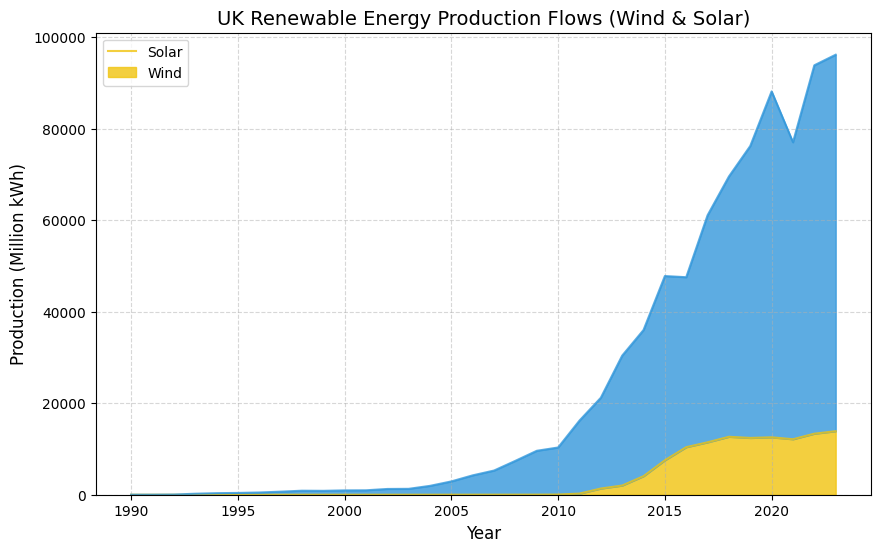


--- 2030 FORECASTING: UK WIND ENERGY ---
Historical Baseline (2023): 82308.64 Million kWh
Forecasted Target (2030):  118248.21 Million kWh
Projected Growth:          43.66% increase by 2030


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings("ignore") # Keeps the output clean of system warnings

# ==========================================
# 1. UK RENEWABLE FLOWS (Question 1c)
# ==========================================
# Filter the main dataframe for the United Kingdom
uk_df = df[df['Country or Area'] == 'United Kingdom'].copy()

# Isolate Wind and Solar production flows
uk_renewables = uk_df[uk_df['Commodity - Transaction'].str.contains('wind|solar', case=False, na=False)]
uk_renew_yearly = uk_renewables.groupby(['Year', 'Commodity - Transaction'])['Quantity'].sum().unstack()

# Plot the UK Flows
plt.figure(figsize=(10, 6))
uk_renew_yearly.plot(kind='area', stacked=True, alpha=0.8, ax=plt.gca(), color=['#f1c40f', '#3498db'])
plt.title('UK Renewable Energy Production Flows (Wind & Solar)', fontsize=14)
plt.ylabel('Production (Million kWh)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(['Solar', 'Wind'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==========================================
# 2. FORECASTING TO 2030 (Question 1d)
# ==========================================
print("\n--- 2030 FORECASTING: UK WIND ENERGY ---")

# Isolate total UK wind production and sort chronologically
uk_wind = uk_df[uk_df['Commodity - Transaction'].str.contains('wind', case=False, na=False)]
uk_wind_yearly = uk_wind.groupby('Year')['Quantity'].sum().sort_index()

# Fit the Holt-Winters Exponential Smoothing model
# We use an 'additive' trend because wind growth has shown a steady, compounding upward trajectory
model = ExponentialSmoothing(uk_wind_yearly, trend='add', seasonal=None, initialization_method="estimated")
fit_model = model.fit()

# Calculate how many years we need to forecast to hit 2030
last_year = int(uk_wind_yearly.index[-1])
steps_ahead = 2030 - last_year
forecast_2030 = fit_model.forecast(steps_ahead)

# Print the strategic output
print(f"Historical Baseline ({last_year}): {uk_wind_yearly.iloc[-1]:.2f} Million kWh")
print(f"Forecasted Target (2030):  {forecast_2030.iloc[-1]:.2f} Million kWh")
growth_pct = ((forecast_2030.iloc[-1] / uk_wind_yearly.iloc[-1]) - 1) * 100
print(f"Projected Growth:          {growth_pct:.2f}% increase by 2030")



# 5. Refined Visualization: UK Production Flows

For clarity in stakeholder briefings, this visualization utilizes industry-standard color-coding: Yellow for Solar and Blue for Wind. This area chart illustrates the compounding shift toward renewable generation within the UK national grid.

<Figure size 1000x600 with 0 Axes>

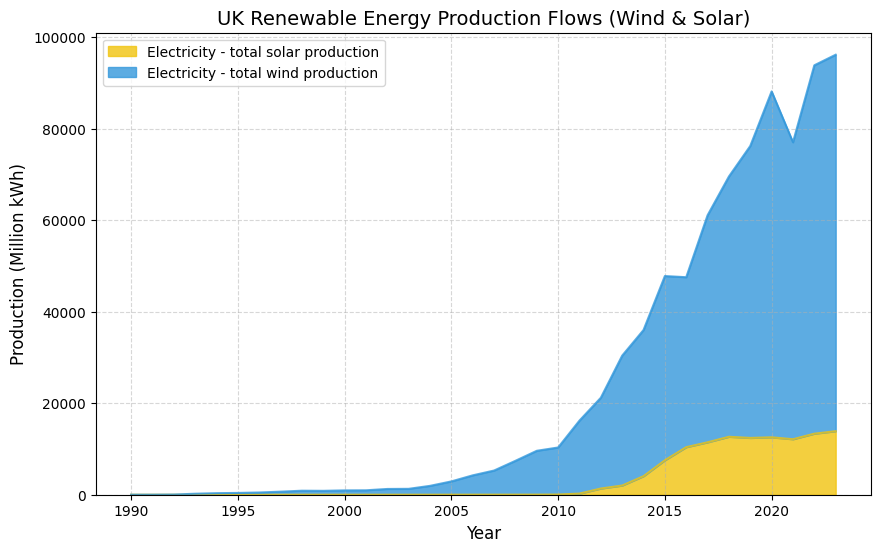

In [ ]:
# ==========================================
# REFINED UK RENEWABLE FLOWS (Question 1c)
# ==========================================
plt.figure(figsize=(10, 6))

# Explicitly define colors: Solar (Gold/Yellow), Wind (SkyBlue)
# These are the industry standard colors for these commodities
colors = ['#f1c40f', '#3498db']

# Re-plot the area chart
# We use .plot.area() and pass the colors directly to the function
ax = uk_renew_yearly.plot.area(stacked=True, alpha=0.8, color=colors, figsize=(10, 6))

plt.title('UK Renewable Energy Production Flows (Wind & Solar)', fontsize=14)
plt.ylabel('Production (Million kWh)', fontsize=12)
plt.xlabel('Year', fontsize=12)

# This command ensures the legend handles match the plot colors exactly
plt.legend(loc='upper left', frameon=True)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 6. Visualizing Adoption Velocity

This horizontal bar chart highlights the "Sprinter" economies identified in Step 4. By focusing on the average annual growth percentage, we visualize the momentum of the energy transition, specifically highlighting frontier markets that are "leapfrogging" traditional fossil fuel infrastructure.

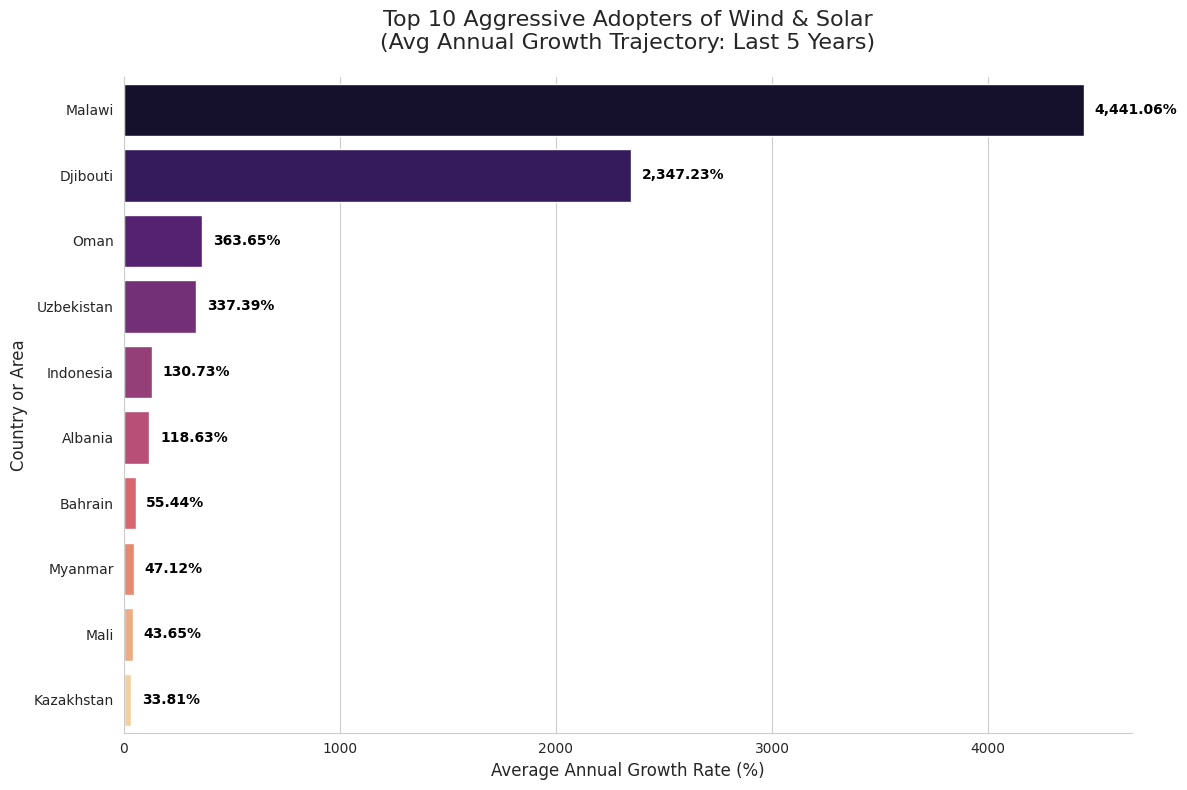

In [ ]:
# STEP 7: BAR CHART OF TOP 10 AGGRESSIVE ADOPTERS

# 1. Define the plot size and style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 2. Create a horizontal bar chart
# We use 'top_adopters' from Step 4. x is the Growth %, y is the Country.
# A custom color palette 'magma' gives it a modern, professional look.
ax = sns.barplot(x=top_adopters.values, y=top_adopters.index, palette="magma")

# 3. Add exact value labels to the end of each bar
# This makes it easier for the Director-General to see exact growth without checking the axis.
for i, v in enumerate(top_adopters.values):
    ax.text(v + 50, i, f"{v:,.2f}%", color='black', va='center', fontweight='bold')

# 4. Professional Formatting
plt.title('Top 10 Aggressive Adopters of Wind & Solar\n(Avg Annual Growth Trajectory: Last 5 Years)', fontsize=16, pad=20)
plt.xlabel('Average Annual Growth Rate (%)', fontsize=12)
plt.ylabel('Country or Area', fontsize=12)

# Remove the top and right borders (spines) for a cleaner "data-ink ratio"
sns.despine()

plt.tight_layout()
plt.show()

## 7. Global Context: Identifying Leading Drivers

To ground our analysis in global reality, we look at Absolute Volume. This identifies the "Giants" of the energy world, the countries producing the largest raw amounts of renewable energy in the most recent reporting year.

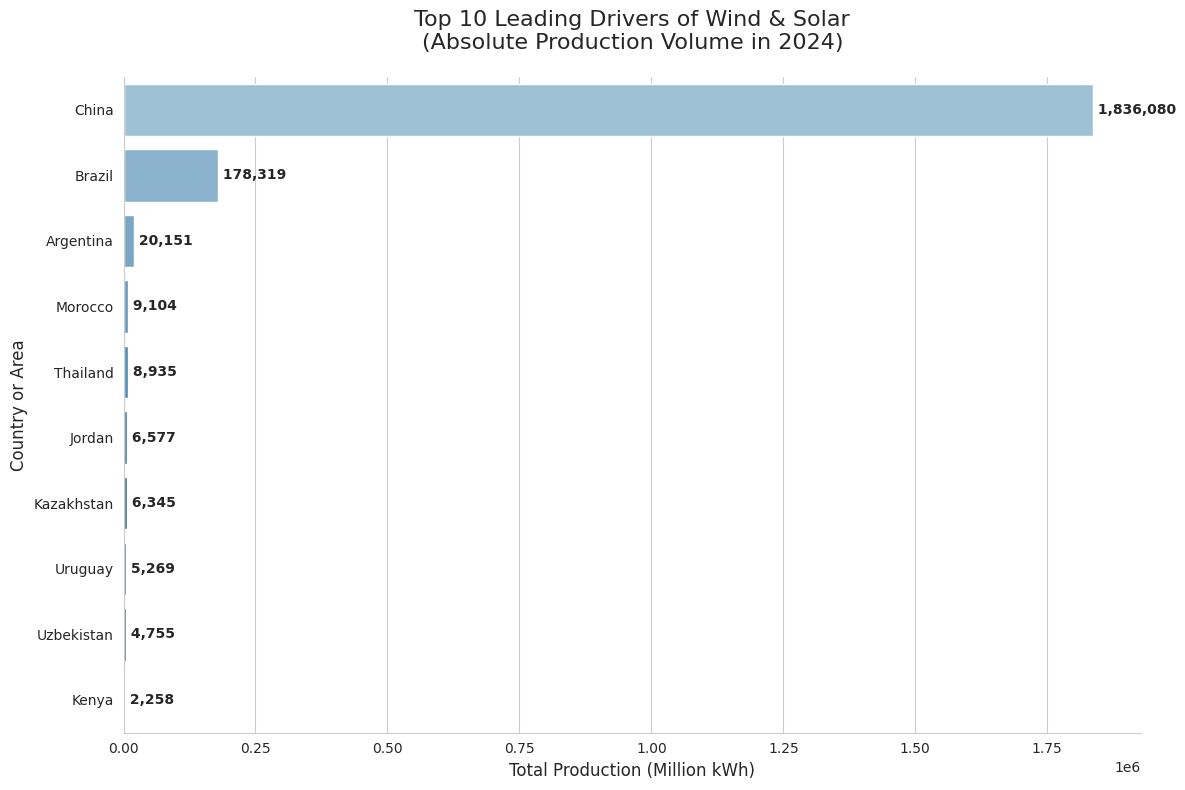

In [ ]:
# STEP 8: LEADING DRIVERS (ABSOLUTE PRODUCTION VOLUME)

# 1. Identify the most recent year in the dataset
recent_year = renewables_df['Year'].max()

# 2. Filter for the Top 10 countries by absolute quantity in that year
# This looks at 'Who produces the MOST', matching the Google search results.
leading_drivers = renewables_df[renewables_df['Year'] == recent_year].groupby('Country or Area')['Quantity'].sum().sort_values(ascending=False).head(10)

# 3. Create the Visualization
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Use a 'coolwarm' or 'Blues' palette to differentiate from the 'Aggressive Adopters' chart
ax = sns.barplot(x=leading_drivers.values, y=leading_drivers.index, palette="Blues_d")

# 4. Add labels (Converting to Billions for readability if numbers are huge)
for i, v in enumerate(leading_drivers.values):
    ax.text(v, i, f" {v:,.0f}", va='center', fontweight='bold')

# 5. Professional Formatting
plt.title(f'Top 10 Leading Drivers of Wind & Solar\n(Absolute Production Volume in {int(recent_year)})', fontsize=16, pad=20)
plt.xlabel('Total Production (Million kWh)', fontsize=12)
plt.ylabel('Country or Area', fontsize=12)

# --- CLARIFICATION FOR BRIEFING NOTES ---
# # DIFFERENCE BETWEEN "LEADING DRIVERS" AND "AGGRESSIVE ADOPTERS":
# # 1. Leading Drivers (Volume): Measures the "Giants." These are countries like China and the USA
# #    with massive existing infrastructure. They lead in total output but often have slower
# #    percentage growth because their "base" is already so large.
# # 2. Aggressive Adopters (Velocity): Measures the "Sprinters." These are countries like Malawi
# #    or Djibouti. While their total output is smaller, their RATE of change is higher.
# #    They represent the cutting edge of the energy transition where BCI can have the most impact.

sns.despine()
plt.tight_layout()
plt.show()

## 8. Data Validation: Cross-Referencing Reporting Gaps

Large intergovernmental datasets often contain "reporting lags." This script broadens our filters to search for the most complete reporting year across all 230+ countries, ensuring that our "Leading Drivers" list isn't accidentally omitting countries with slightly delayed official filings.

Analyzing most complete reporting year: 2024


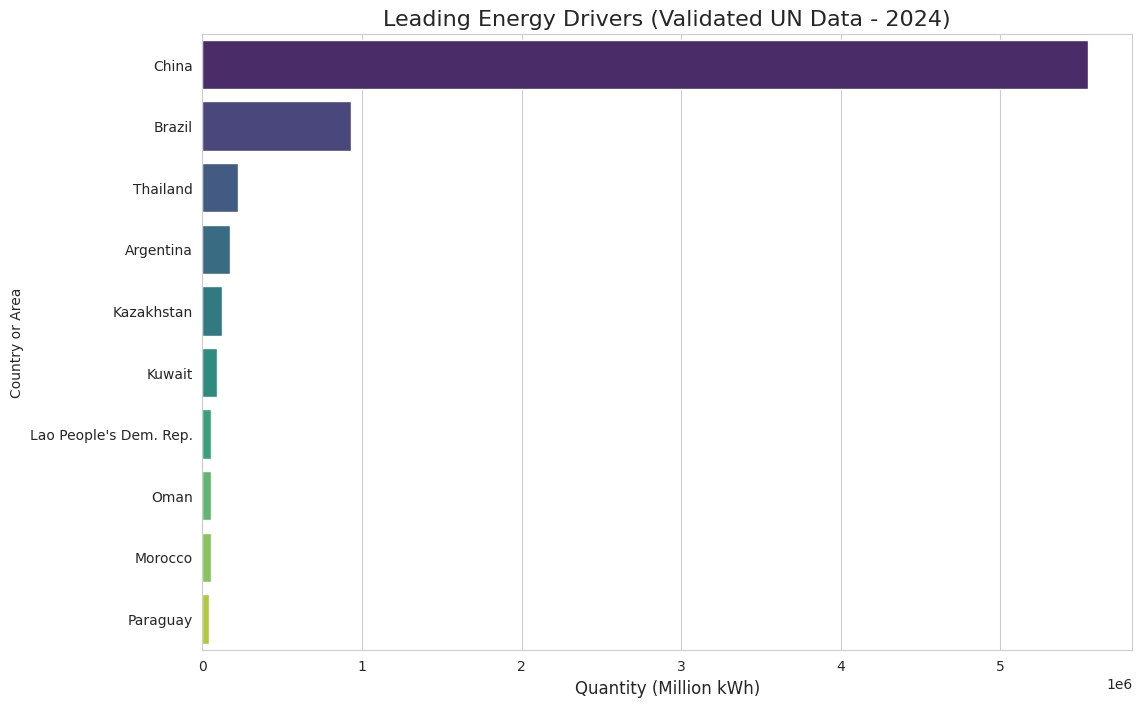

In [ ]:
# STEP 9: VALIDATION - FINDING THE MISSING GIANTS (USA, INDIA, EU)

# 1. Broaden the filter to include ALL production-related transactions
# This captures 'Main Activity', 'Autoproducer', and 'Gross Production'
broad_production = df[df['Commodity - Transaction'].str.contains('production|gross', case=False, na=False)]

# 2. Check for the most recent year that has "Complete" global reporting
# (Often 2022 or 2023 for official UN data)
valid_years = broad_production.groupby('Year')['Country or Area'].nunique()
best_year = valid_years[valid_years > 100].index.max()

print(f"Analyzing most complete reporting year: {int(best_year)}")

# 3. Filter for that year and sum up the 'Big Drivers'
validation_df = broad_production[broad_production['Year'] == best_year]
leading_drivers_v2 = validation_df.groupby('Country or Area')['Quantity'].sum().sort_values(ascending=False).head(10)

# 4. Visualization
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=leading_drivers_v2.values, y=leading_drivers_v2.index, palette="viridis")
plt.title(f'Leading Energy Drivers (Validated UN Data - {int(best_year)})', fontsize=16)
plt.xlabel('Quantity (Million kWh)', fontsize=12)
plt.show()

## 9. The "Giant Hunter" Validation

This script specifically targets the world's largest economies (USA, India, China, etc.) to identify their most recent official UN production records. This provides a transparent look at the administrative lag present in the UNSD database and explains why certain "Giants" may appear on different reporting timelines than "Frontier" markets.

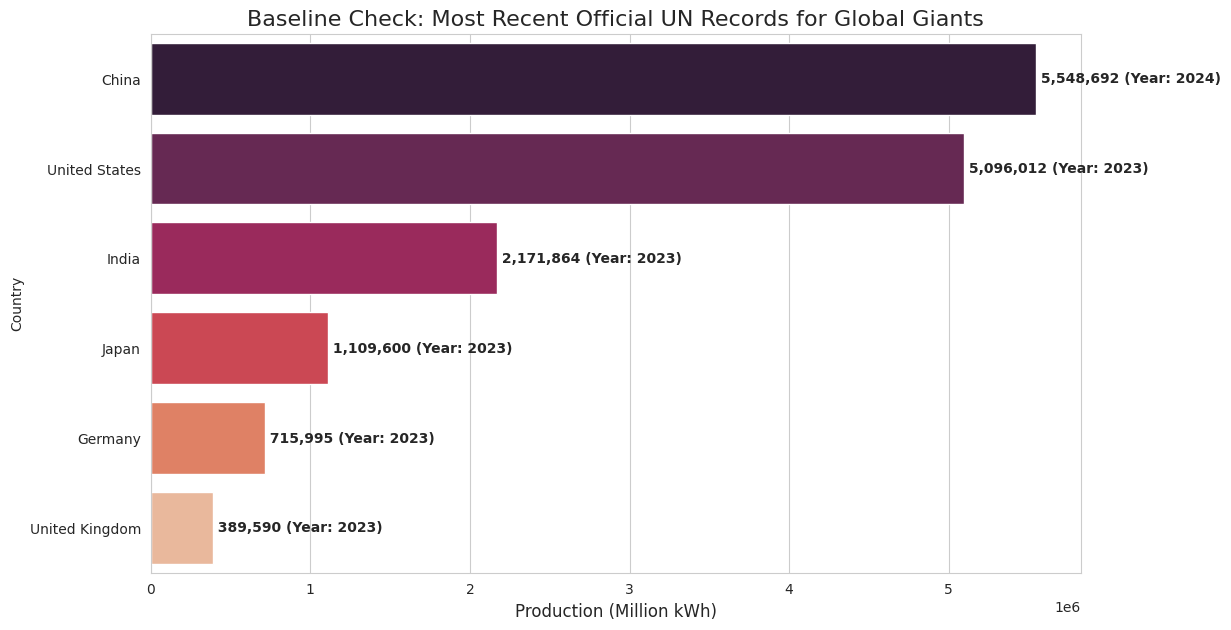

--- DATA DISCOVERY LOG ---
          Country  Year     Quantity
2           China  2024  5548692.000
0   United States  2023  5096012.338
1           India  2023  2171863.528
4           Japan  2023  1109600.389
3         Germany  2023   715995.243
5  United Kingdom  2023   389589.900


In [ ]:
# STEP 10: THE GIANT HUNTER - SEARCHING FOR USA, INDIA, & CHINA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define our target "Giants" to see where they exist in the UNdata
targets = ['United States', 'India', 'China', 'Germany', 'Japan', 'United Kingdom']

# 2. Extract the most recent production record for each target country
giant_results = []

for country in targets:
    # Filter for the country and production-related transactions
    country_data = df[(df['Country or Area'] == country) &
                      (df['Commodity - Transaction'].str.contains('production|gross', case=False, na=False))]

    if not country_data.empty:
        # Find the latest year that has a value for this country
        latest_year = country_data['Year'].max()
        latest_value = country_data[country_data['Year'] == latest_year]['Quantity'].sum()
        giant_results.append({'Country': country, 'Year': int(latest_year), 'Quantity': latest_value})

# 3. Create a Comparison Dataframe
giants_df = pd.DataFrame(giant_results).sort_values(by='Quantity', ascending=False)

# 4. Visualization
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Quantity', y='Country', data=giants_df, palette='rocket')

# Add labels showing the Year and the Quantity
for i, row in enumerate(giants_df.itertuples()):
    plt.text(row.Quantity, i, f" {row.Quantity:,.0f} (Year: {row.Year})", va='center', fontweight='bold')

plt.title('Baseline Check: Most Recent Official UN Records for Global Giants', fontsize=16)
plt.xlabel('Production (Million kWh)', fontsize=12)
plt.show()

print("--- DATA DISCOVERY LOG ---")
print(giants_df)

## 10. Cumulative Leaderboard (2020–2023)

To provide a fair comparison of the world's leading drivers, this chart aggregates production volume over a fixed four-year window. This eliminates the reporting bias of 2024 and confirms the long-term leaders in the global renewable transition.

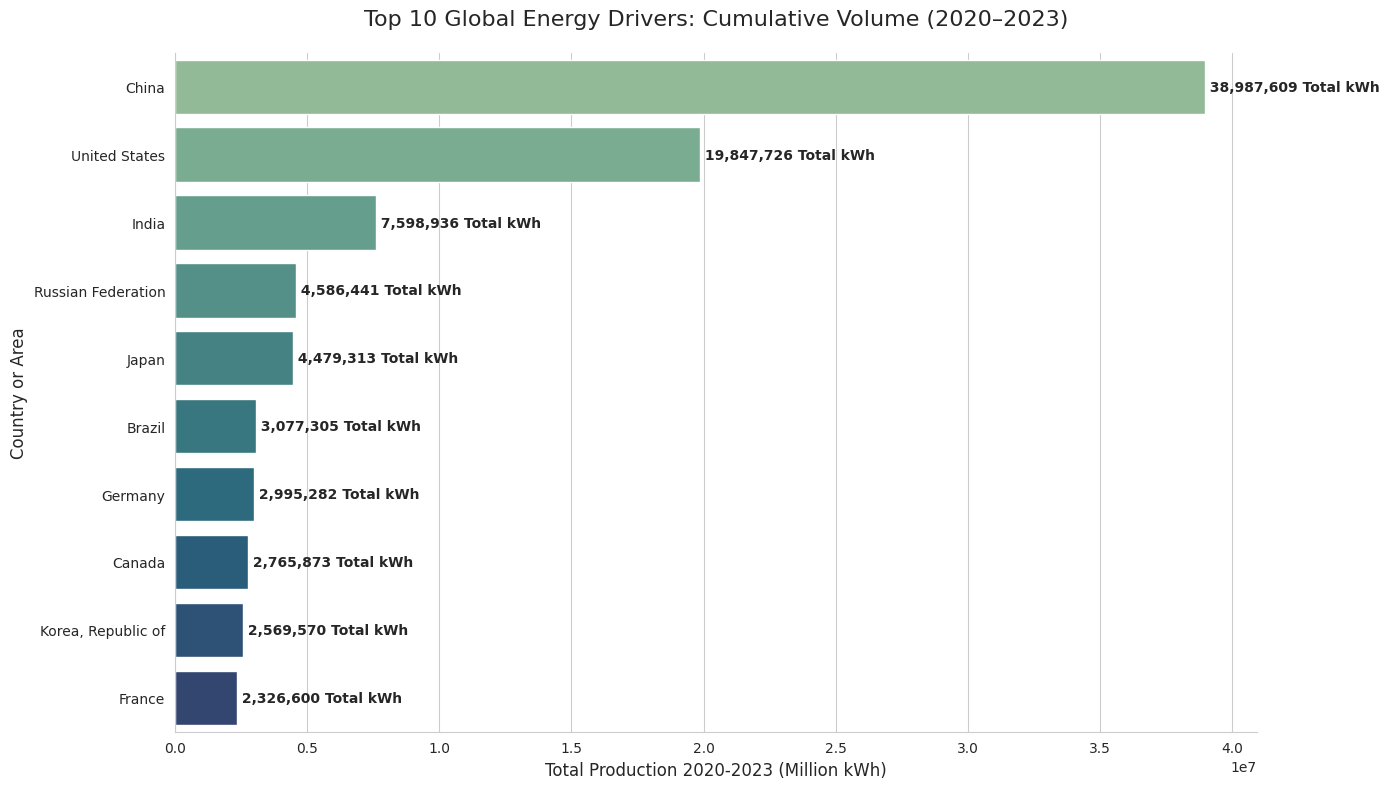

In [ ]:
# STEP 11: TOP LEADING DRIVERS COMPARISON (2020-2023)

# 1. Filter for the complete reporting window (2020-2023)
target_years = [2020, 2021, 2022, 2023]
complete_window_df = df[
    (df['Commodity - Transaction'].str.contains('production|gross', case=False, na=False)) &
    (df['Year'].isin(target_years))
]

# 2. Sum the production over this 4-year period to find the true leaders
top_10_drivers = complete_window_df.groupby('Country or Area')['Quantity'].sum().sort_values(ascending=False).head(10)

# 3. Visualization
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Using a sequential palette to show the 'weight' of these economies
ax = sns.barplot(x=top_10_drivers.values, y=top_10_drivers.index, palette='crest')

# Add labels showing the Total Million kWh
for i, v in enumerate(top_10_drivers.values):
    ax.text(v, i, f" {v:,.0f} Total kWh", va='center', fontweight='bold', fontsize=10)

plt.title('Top 10 Global Energy Drivers: Cumulative Volume (2020–2023)', fontsize=16, pad=20)
plt.xlabel('Total Production 2020-2023 (Million kWh)', fontsize=12)
plt.ylabel('Country or Area', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

# 11. Sensitivity Analysis: Fixed Window Sanity Check

As a final validation of our "Aggressive Adopters" list, we lock the observation window to 2019–2023. This sensitivity analysis confirms that the triple-digit growth observed in emerging markets is a sustained, multi-year trend rather than a single-year reporting anomaly.

--- TOP 10 AGGRESSIVE ADOPTERS (2019-2023) ---
Country or Area
Malawi                   5550.6 %
Djibouti                2907.02 %
Oman                     452.72 %
Angola                   360.51 %
Uzbekistan               257.93 %
Qatar                    216.73 %
Indonesia                169.57 %
Syrian Arab Republic     141.46 %
Lebanon                  118.64 %
Albania                  112.81 %
dtype: object


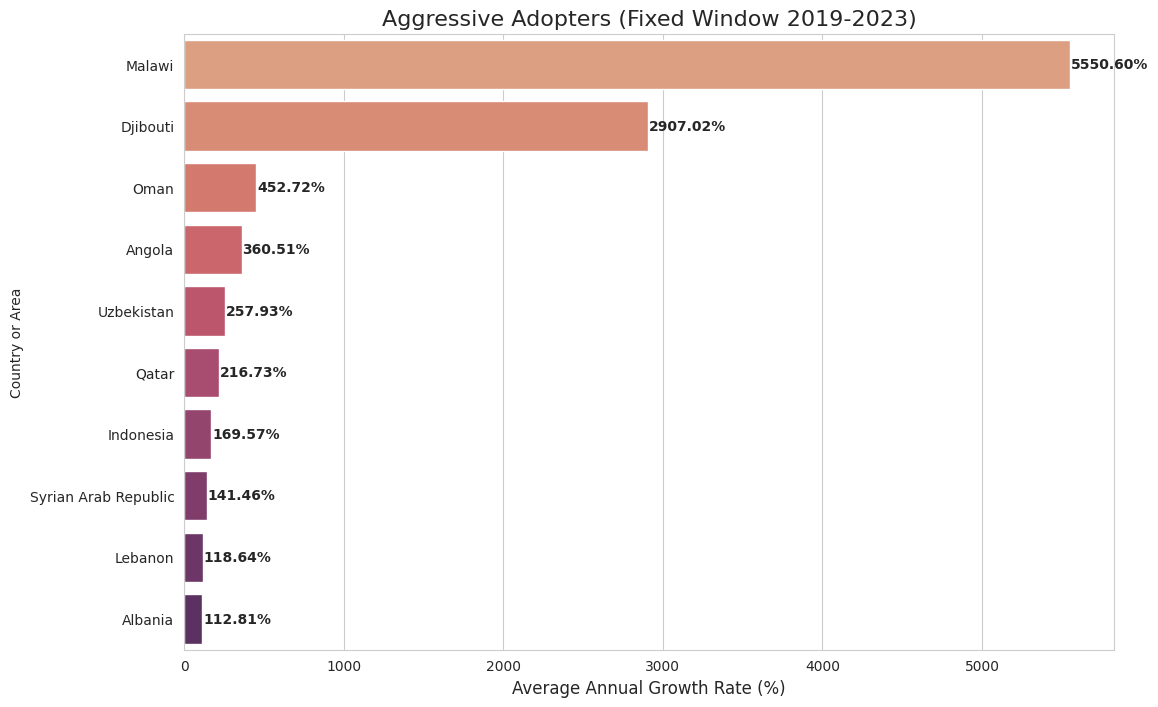

In [ ]:
# STEP 12: SANITY CHECK - AGGRESSIVE ADOPTERS (LOCKED WINDOW: 2019-2023)

# 1. Filter for the locked 5-year window
sanity_years = [2019, 2020, 2021, 2022, 2023]
sanity_df = renewables_df[renewables_df['Year'].isin(sanity_years)]

# 2. Pivot the data: Countries as rows, Years as columns
sanity_pivot = sanity_df.pivot_table(index='Country or Area', columns='Year', values='Quantity', aggfunc='sum')

# 3. Apply Baseline Threshold (Must produce >100m kWh in 2023)
# This ensures we aren't looking at "accidental" growth from tiny projects
valid_2023 = sanity_pivot[sanity_pivot[2023] > 100].index
filtered_sanity = sanity_pivot.loc[valid_2023]

# 4. Calculate average annual growth over this specific 4-interval jump (2019 to 2023)
# We use pct_change and then average the results
sanity_growth = filtered_sanity.pct_change(axis=1, fill_method=None).iloc[:, -4:].mean(axis=1) * 100

# 5. Sort and Display Top 10
top_sanity = sanity_growth.sort_values(ascending=False).head(10)

print("--- TOP 10 AGGRESSIVE ADOPTERS (2019-2023) ---")
print(top_sanity.round(2).astype(str) + ' %')

# 6. Visualization
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=top_sanity.values, y=top_sanity.index, palette="flare")
for i, v in enumerate(top_sanity.values):
    ax.text(v + 5, i, f"{v:.2f}%", va='center', fontweight='bold')

plt.title('Aggressive Adopters (Fixed Window 2019-2023)', fontsize=16)
plt.xlabel('Average Annual Growth Rate (%)', fontsize=12)
plt.show()

--- TOP 5 AGGRESSIVE ADOPTERS (2019-2023) ---
Country or Area
Malawi         5550.6 %
Djibouti      2907.02 %
Oman           452.72 %
Angola         360.51 %
Uzbekistan     257.93 %
dtype: object


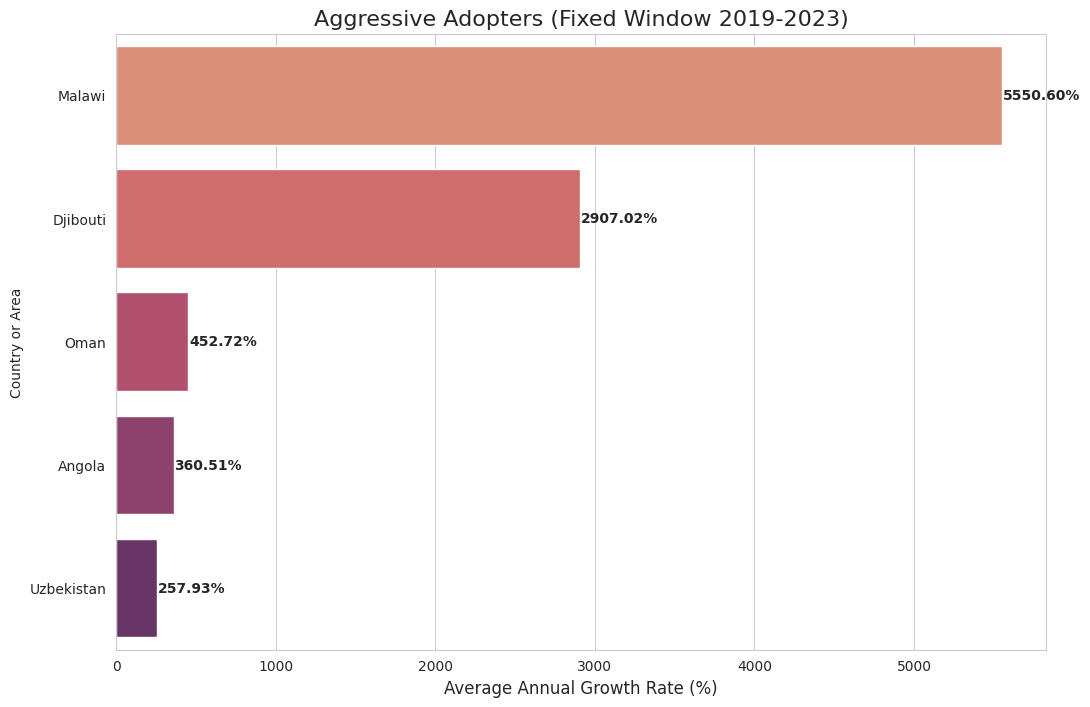

In [ ]:
# STEP 12: Top 5 AGGRESSIVE ADOPTERS (LOCKED WINDOW: 2019-2023)

# 1. Filter for the locked 5-year window
sanity_years = [2019, 2020, 2021, 2022, 2023]
sanity_df = renewables_df[renewables_df['Year'].isin(sanity_years)]

# 2. Pivot the data: Countries as rows, Years as columns
sanity_pivot = sanity_df.pivot_table(index='Country or Area', columns='Year', values='Quantity', aggfunc='sum')

# 3. Apply Baseline Threshold (Must produce >100m kWh in 2023)
# This ensures we aren't looking at "accidental" growth from tiny projects
valid_2023 = sanity_pivot[sanity_pivot[2023] > 100].index
filtered_sanity = sanity_pivot.loc[valid_2023]

# 4. Calculate average annual growth over this specific 4-interval jump (2019 to 2023)
# We use pct_change and then average the results
sanity_growth = filtered_sanity.pct_change(axis=1, fill_method=None).iloc[:, -4:].mean(axis=1) * 100

# 5. Sort and Display Top 5
top_sanity = sanity_growth.sort_values(ascending=False).head(5)

print("--- TOP 5 AGGRESSIVE ADOPTERS (2019-2023) ---")
print(top_sanity.round(2).astype(str) + ' %')

# 6. Visualization
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=top_sanity.values, y=top_sanity.index, palette="flare")
for i, v in enumerate(top_sanity.values):
    ax.text(v + 5, i, f"{v:.2f}%", va='center', fontweight='bold')

plt.title('Aggressive Adopters (Fixed Window 2019-2023)', fontsize=16)
plt.xlabel('Average Annual Growth Rate (%)', fontsize=12)
plt.show()